# Best-of-N

**Paper**: [WebGPT: Browser-assisted question-answering with human feedback](https://arxiv.org/abs/2112.09332)

**Authors**: Reiichiro Nakano, Jacob Hilton, Suchir Balaji, Jeff Wu, Long Ouyang, Christina Kim, Christopher Hesse, Shantanu Jain, Vineet Kosaraju, William Saunders, Xu Jiang, Karl Cobbe, Tyna Eloundou, Gretchen Krueger, Kevin Button, Matthew Knight, Benjamin Chess, John Schulman

Best-of-N sampling is a standard inference-time alignment baseline. It samples several full-length continuations from the base model and returns the single highest-scoring one under a supplied sequence scorer. Pairing the driver with a majority-vote scorer recovers self-consistency, while pairing it with a metric scorer gives metric-guided reranking.

Best-of-N is a decoding driver in our toolkit built on the generic search driver, mapping onto a single search iteration (`num_candidates=n`, `keep_k=1`, `max_iterations=1`, `propose_mode="sample"`) whose one segment spans the whole `max_new_tokens` budget. Each sampled continuation is a full rollout. This means that any composed logits processor (for example RAD) steers every sample. Parameters for the scorer are passed at inference time via `runtime_kwargs={"reward_params": {...}}`.

## Method parameters

| parameter | type | description |
| --------- | ---- | ----------- |
| `n` | `int` | Number of full-length continuations to sample and rank |
| `scorer` | `Callable` | A sequence scorer `(prompt, continuations, params) -> list[float]` (the highest-scoring sample is returned) |

## Setup

If running this from a Google Colab notebook, uncomment the clone cell below. It is not necessary when running from a virtual environment where the package is already installed.

In [1]:
# !git clone https://github.com/IBM/steerability.git
# %cd Steerability

The following authentication steps may be necessary to access any gated models (after being granted access by Hugging Face). Uncomment the following if you need to log in to the Hugging Face Hub:

In [2]:
# !pip install -q python-dotenv
# from dotenv import load_dotenv
# import os

# load_dotenv()
# token = os.getenv("HUGGINGFACE_TOKEN")
# from huggingface_hub import login
# login(token=token)

## Example: reranking by keyword coverage

The scorer is any callable `(prompt, continuations, params) -> list[float]`, where `params` is whatever was passed as `reward_params` at generation time. We define a scorer that counts how many required keywords a continuation covers, then ask for a single sentence that uses all of them. We use `Qwen/Qwen2.5-1.5B-Instruct` and load it once. Every pipeline below wraps this one model (`SteeringPipeline` accepts a preloaded `model` and `tokenizer`), which avoids re-downloading between configurations.

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer, set_seed

from steerability.algorithms.core.steering_pipeline import SteeringPipeline
from steerability.algorithms.output_control.best_of_n.control import BestOfN
from steerability.evaluation.plotting import apply_plot_style, plot_sensitivity

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, device_map="auto", dtype="auto")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

The scorer rewards one point per covered keyword. With sixteen required words and a 56-token budget, no single sample fits them all and most drop several. This gives reranking headroom because selection can only help when samples differ in score.

In [4]:
def keyword_coverage(prompt, continuations, params):
    terms = [t.lower() for t in params.get("key_terms", [])]
    return [float(sum(term in c.lower() for term in terms)) for c in continuations]


KEY_TERMS = [
    "cat", "couch", "sun", "tea", "nap", "book", "rain", "socks",
    "lamp", "blanket", "pillow", "candle", "sweater", "toast", "radio", "slippers",
]

### Baseline: a single sample (`n=1`)

With one candidate, taking the argmax over one score is a no-op, i.e., `n=1` is plain sampling. We fix the seed to keep the runs below comparable, and print the keyword score alongside the output.

In [5]:
pipeline_n1 = SteeringPipeline(model=model, tokenizer=tokenizer, controls=[BestOfN(n=1, scorer=keyword_coverage)])
pipeline_n1.steer()

prompt = (
    "Write one sentence about a lazy afternoon at home that mentions all of these words: "
    "cat, couch, sun, tea, nap, book, rain, socks, lamp, blanket, pillow, candle, sweater, "
    "toast, radio, slippers."
)
chat = tokenizer.apply_chat_template(
    [{"role": "user", "content": prompt}],
    tokenize=False,
    add_generation_prompt=True,
)
inputs = tokenizer(chat, return_tensors="pt").to(model.device)

set_seed(42)
output = pipeline_n1.generate(
    input_ids=inputs["input_ids"],
    runtime_kwargs={"reward_params": {"key_terms": KEY_TERMS}},
    max_new_tokens=56,
    do_sample=True,
    pad_token_id=tokenizer.eos_token_id,
)
text_n1 = tokenizer.decode(output[0], skip_special_tokens=True)
print(text_n1)
print(f"\nkeyword score: {keyword_coverage(prompt, [text_n1], {'key_terms': KEY_TERMS})[0]:.0f}/{len(KEY_TERMS)}")

On a rainy afternoon, my fluffy cat curls up on the comfy couch to enjoy a warm cup of tea while I read a book and take a long nap, wrapped in a cozy blanket with my favorite woolen socks and a soft pillow beside me; meanwhile, I hear the gentle
keyword score: 9/16


A single sample reflects whatever sampling path it happens to take. The score records how many of the sixteen keywords it covered.

### Best of 8

We repeat the run with the same seed and prompt, but the driver now proposes eight full continuations, scores each with `keyword_coverage`, and returns the argmax.

In [6]:
pipeline_n8 = SteeringPipeline(model=model, tokenizer=tokenizer, controls=[BestOfN(n=8, scorer=keyword_coverage)])
pipeline_n8.steer()

set_seed(42)
output = pipeline_n8.generate(
    input_ids=inputs["input_ids"],
    runtime_kwargs={"reward_params": {"key_terms": KEY_TERMS}},
    max_new_tokens=56,
    do_sample=True,
    pad_token_id=tokenizer.eos_token_id,
)
text_n8 = tokenizer.decode(output[0], skip_special_tokens=True)
print(text_n8)
print(f"\nkeyword score: {keyword_coverage(prompt, [text_n8], {'key_terms': KEY_TERMS})[0]:.0f}/{len(KEY_TERMS)}")

On a lazy afternoon, the fluffy cat curls up on the warm couch, sips hot tea while napping, surrounded by books and blankets, as gentle rain falls outside, creating an enchanting atmosphere with the soft glow of a lamp and cozy socks, all while enjoying the comforting
keyword score: 9/16


The returned continuation is the highest scorer among the eight candidates. Since the model itself is unchanged, any improvement comes from selection. Note that one pair of seeded runs is a noisy comparison (a single sample can get lucky). The sweep below averages over trials.

### The driver's internal loop

One search iteration consists of three steps (propose, score, keep). The cell below reproduces it directly against the same model by sampling eight continuations with `num_return_sequences=8`, scoring them with the same scorer, and taking the argmax. `BestOfN` automates this loop and generalizes it, since the pipeline's composed logits processors and stopping criteria apply to every rollout.

In [7]:
set_seed(42)
rollouts = model.generate(
    input_ids=inputs["input_ids"],
    attention_mask=inputs["attention_mask"],
    max_new_tokens=56,
    do_sample=True,
    num_return_sequences=8,
    pad_token_id=tokenizer.eos_token_id,
)
continuations = tokenizer.batch_decode(rollouts[:, inputs["input_ids"].shape[1]:], skip_special_tokens=True)
scores = keyword_coverage(prompt, continuations, {"key_terms": KEY_TERMS})

for score, continuation in sorted(zip(scores, continuations), reverse=True):
    print(f"[{score:.0f}] {continuation}")

[9] On a rainy day, I snuggled up with my favorite blanket and pillow on the cozy couch, sipping hot cocoa from a steaming mug while reading a book, listening to the radio, and napping in front of the lamp, all thanks to the warm glow of
[9] On a rainy afternoon, I lazily lounged on the comfortable couch with my favorite book while sipping tea and reading, enjoying the warmth from the lamp as I napped under a fluffy blanket, watched TV with my slippers on, read another chapter, listened to my radio
[9] On a lazy afternoon, the fluffy cat curls up on the warm couch, sips hot tea while napping, surrounded by books and blankets, as gentle rain falls outside, creating an enchanting atmosphere with the soft glow of a lamp and cozy socks, all while enjoying the comforting
[8] On a rainy afternoon at home, I snuggled with my fluffy cat on the cozy couch, sipped hot tea from an old mug while napping, and listened to the gentle sound of my radio as I read a book by the warm light of a lamp.
[7]

The spread across the eight samples is what best-of-N exploits. Every rollout misses some of the sixteen words, the best cover the most, and the driver keeps the top row of this list.

### Scaling `n`

Since each candidate is a full rollout, best-of-N costs `n` times the decode compute of a single generation. To measure what that compute buys, we sample five pools of sixteen candidates (one per seed) and, within each pool, take the best score among the first `n` candidates. This is the winner a best-of-`n` selection over that prefix returns, and reusing one pool across all `n` keeps the comparison free of seed-to-seed sampling noise, i.e., within a trial the curve can only go up as `n` grows.

In [8]:
ns = [1, 2, 4, 8, 16]
num_trials = 5

records = []
for seed in range(num_trials):
    set_seed(seed)
    pool = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=56,
        do_sample=True,
        num_return_sequences=max(ns),
        pad_token_id=tokenizer.eos_token_id,
    )
    pool_texts = tokenizer.batch_decode(pool[:, inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    pool_scores = keyword_coverage(prompt, pool_texts, {"key_terms": KEY_TERMS})
    for n in ns:
        records.append({"n": n, "trial": seed, "keyword_score": max(pool_scores[:n])})

trials = pd.DataFrame(records)
trials.pivot(index="trial", columns="n", values="keyword_score")

n,1,2,4,8,16
trial,,,,,
0,9.0,9.0,9.0,10.0,10.0
1,7.0,7.0,7.0,9.0,9.0
2,6.0,8.0,8.0,10.0,10.0
3,7.0,7.0,9.0,9.0,9.0
4,8.0,8.0,11.0,11.0,11.0


We plot the mean winner score at each `n` with the per-trial scores overlaid, using `plot_sensitivity` from `steerability.evaluation.plotting`. The curve shows how output score scales with sampling compute.

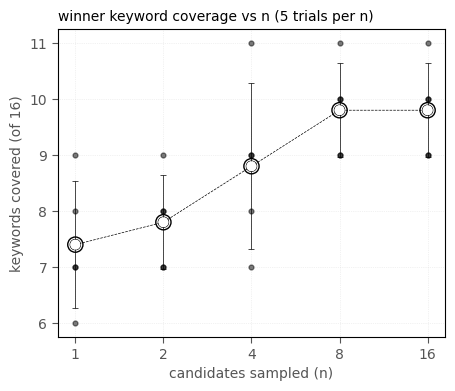

In [9]:
apply_plot_style()

summary = trials.groupby("n", as_index=False)["keyword_score"].agg(keyword_score_mean="mean", keyword_score_std="std")
ax = plot_sensitivity(
    summary,
    metric="keyword_score",
    sweep_col="n",
    per_trial_data=trials,
    metric_label=f"keywords covered (of {len(KEY_TERMS)})",
    sweep_label="candidates sampled (n)",
    title=f"winner keyword coverage vs n ({num_trials} trials per n)",
)
ax.set_xscale("log", base=2)
ax.set_xticks(ns)
ax.set_xticklabels([str(n) for n in ns])
ax.tick_params(axis="x", which="minor", bottom=False)

The winner's score climbs with `n` because a larger pool is more likely to contain a sentence that covers more of the sixteen words, and the curve flattens once the 56-token budget becomes the binding constraint. In practice, `n` is the parameter that trades output score against decode compute.

## Example: self-consistency with `MajorityVoteScorer`

Swapping the scorer changes the method. `MajorityVoteScorer` scores each continuation by how many of the others share its extracted answer. As a result, best-of-N with this scorer returns a continuation carrying the plurality answer over `n` sampled reasoning paths. This is self-consistency (Wang et al., 2022), obtained through the choice of scorer.

Self-consistency needs a problem in the band where sampled reasoning paths disagree, i.e., easy enough that correct paths are common but hard enough that any single path often fails. A trivial problem gives unanimous votes (leaving nothing to select on), while a problem past the model's reach scatters the votes with no correct plurality to find. We use a Level 2 problem from MATH-500 (row `test/number_theory/686.json` of the `HuggingFaceH4/MATH-500` subset of MATH), which asks for the units digit of $18^6$. The correct path only has to track the units digit through the power cycle (8, 4, 2, 6, ...), and most sampled paths manage it, but a path that miscounts the cycle lands on the units digit of a neighboring power. This means that wrong answers concentrate on a few plausible digits rather than scattering, which is the regime where a plurality vote helps. The correct answer is 4.

The scorer takes an `answer_extractor`, and the extractor defines what counts as the same vote. We use `extract_numeric_answer` from `steerability.utils.answers`, which anchors on a final `Answer:` line or a `\boxed{...}` wrapper, parses integers, fractions, and decimals, and canonicalizes with `fractions.Fraction` so that `4/6`, `\frac{2}{3}`, and `2/3` fall into one vote bucket (with a last-number fallback for responses that ignore the format).

In [10]:
from steerability.algorithms.output_control.common.scorers import MajorityVoteScorer
from steerability.utils.answers import extract_numeric_answer

# level 2 problem from MATH-500 (HuggingFaceH4/MATH-500, row test/number_theory/686.json); the answer is 4
MATH_PROBLEM = "Find the units digit of $18^6.$"
MATH_ANSWER = "4"

majority_pipeline = SteeringPipeline(
    model=model,
    tokenizer=tokenizer,
    controls=[BestOfN(n=16, scorer=MajorityVoteScorer(answer_extractor=extract_numeric_answer))],
)
majority_pipeline.steer()

math_prompt = (
    f"{MATH_PROBLEM} Work through it step by step, then end your response with "
    '"Answer: <value>", where <value> is an integer or a fraction in lowest terms.'
)
math_chat = tokenizer.apply_chat_template(
    [{"role": "user", "content": math_prompt}],
    tokenize=False,
    add_generation_prompt=True,
)
math_inputs = tokenizer(math_chat, return_tensors="pt").to(model.device)

set_seed(42)
output = majority_pipeline.generate(
    input_ids=math_inputs["input_ids"],
    max_new_tokens=640,
    do_sample=True,
    temperature=0.8,
    pad_token_id=tokenizer.eos_token_id,
)
majority_text = tokenizer.decode(output[0], skip_special_tokens=True)
print(majority_text)
print(f"\nextracted answer: {extract_numeric_answer(majority_text)} (target {MATH_ANSWER})")

To find the units digit of \(18^6\), we can focus on the units digit of the base number 18, which is 8.
### Step-by-Step Solution:
#### Step 1: Determine the pattern for the units digits of powers of 8.
We observe that:
- \(8^1 = 8\) (units digit is 8)
- \(8^2 = 64\) (units digit is 4)
- \(8^3 = 512\) (units digit is 2)
- \(8^4 = 4096\) (units digit is 6)
From this, we notice that the units digits repeat every 4 numbers: 8, 4, 2, 6.
#### Step 2: Use the repeating pattern to determine the units digit of \(8^{6}\).
Since the units digits repeat every 4 numbers, we can find the position of 6 within one cycle by taking the remainder when 6 is divided by 4:
\[ 6 \mod 4 = 2 \]
This tells us that the units digit of \(8^6\) will be the same as the units digit of \(8^2\).
#### Step 3: Find the units digit of \(8^2\).
Using our observation from Step 1:
\[ 8^2 = 64 \]
The units digit of 64 is 4.
Therefore, the units digit of \(18^6\) is **4**.
### Answer: 4
extracted answer: 4 (target 4)


### Comparison: a single greedy answer

The claim of self-consistency is that the plurality over sampled reasoning paths is more reliable than the single path greedy decoding commits to. For the comparison, we decode the same prompt greedily, without the driver.

In [11]:
greedy_ids = model.generate(
    input_ids=math_inputs["input_ids"],
    attention_mask=math_inputs["attention_mask"],
    max_new_tokens=640,
    do_sample=False,
    pad_token_id=tokenizer.eos_token_id,
)
greedy_text = tokenizer.decode(greedy_ids[0][math_inputs["input_ids"].shape[1]:], skip_special_tokens=True)
print(greedy_text)
print(f"\nextracted answer: {extract_numeric_answer(greedy_text)} (target {MATH_ANSWER})")

To find the units digit of \( 18^6 \), we can focus on the units digits of the powers of 18 because only the units digit affects the units digit of the result.
First, let's look at the pattern in the units digits of the powers of 18:
- \( 18^1 = 18 \) (units digit is 8)
- \( 18^2 = 324 \) (units digit is 4)
- \( 18^3 = 5832 \) (units digit is 2)
- \( 18^4 = 104976 \) (units digit is 6)
- \( 18^5 = 19306880 \) (units digit is 0)
We observe that after \( 18^4 \), the units digit starts repeating every four numbers due to the cyclical nature of the units digits when raised to successive powers.
Now, since we need to find the units digit of \( 18^6 \):
\[ 18^6 = (18^4) \times (18^2) \]
From our observation above, we know:
- The units digit of \( 18^4 \) is 6.
- The units digit of \( 18^2 \) is 4.
Therefore,
\[ 18^6 = 6 \times 4 \]
The units digit of this product is the same as the units digit of \( 6 \times 4 \).
Calculating \( 6 \times 4 \):
\[ 6 \times 4 = 24 \]
The units digit of 24 is 

A single reasoning path must be correct at every step, and greedy decoding commits to one such path. Whether that path happens to be sound is a property of the model and prompt, not something the decoding strategy controls. The plurality over sixteen sampled paths is more robust because wrong paths scatter across minority clusters while correct paths agree (Wang et al.'s result). This robustness gap grows as problems become harder than what a single path reliably solves.

### The vote distribution

The driver's argmax is over agreement counts. This means that the relevant quantity is the histogram of extracted answers across the pool. The cell below repeats the proposal step directly by sampling sixteen continuations and tabulating the votes the scorer counted.

In [12]:
from collections import Counter

set_seed(42)
rollouts = model.generate(
    input_ids=math_inputs["input_ids"],
    attention_mask=math_inputs["attention_mask"],
    max_new_tokens=640,
    do_sample=True,
    temperature=0.8,
    num_return_sequences=16,
    pad_token_id=tokenizer.eos_token_id,
)
continuations = tokenizer.batch_decode(rollouts[:, math_inputs["input_ids"].shape[1]:], skip_special_tokens=True)
votes = Counter(extract_numeric_answer(c) for c in continuations)
votes

Counter({'4': 13, '6': 3})

The plurality bucket matches what `BestOfN` returned above, and the minority buckets are the wrong paths that any single sample (greedy included) risks committing to. In the plot below, the bar for the correct answer is highlighted.

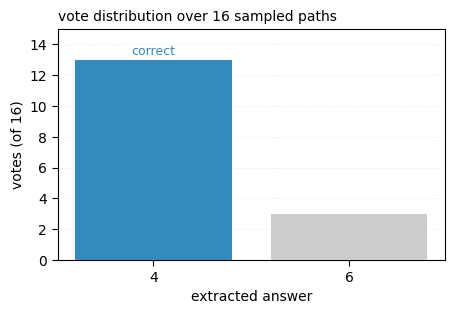

In [13]:
apply_plot_style()

vote_order = votes.most_common()
labels = [answer if answer else "none" for answer, _ in vote_order]
counts = [count for _, count in vote_order]
colors = ["#348ABD" if answer == MATH_ANSWER else "#cccccc" for answer, _ in vote_order]

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(labels, counts, color=colors, edgecolor="none", zorder=3)
for i, (answer, count) in enumerate(vote_order):
    if answer == MATH_ANSWER:
        ax.annotate("correct", (i, count), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=9, color="#348ABD")
ax.set_xlabel("extracted answer")
ax.set_ylabel(f"votes (of {len(continuations)})")
ax.set_title(f"vote distribution over {len(continuations)} sampled paths", loc="left", fontweight="medium", fontsize=10)
ax.set_ylim(0, max(counts) + 2)
ax.yaxis.get_major_locator().set_params(integer=True)
ax.grid(True, axis="y", zorder=0)

### Takeaway

Best-of-N is a reasonable first method to try when a scoring function is available, since it requires no training, composes with other controls, and costs `n` full decodes per output. The choice of scorer determines the method, as this notebook shows twice with the same driver (keyword reranking, then self-consistency via `MajorityVoteScorer`). The shipped scorers live in `steerability.algorithms.output_control.common.scorers`.

Because every candidate is a full rollout through the composed stacks, a step-level control steers all `n` samples. For example, running RAD under `BestOfN` reranks already-detoxified candidates ([rad.ipynb](rad.ipynb)). For iterative segment-level search with the same scorer contract, see DeAL ([deal.ipynb](deal.ipynb)). See the [output control](https://ibm.github.io/steerability/concepts/controls/#output-control) section of the docs for the full family.